In [ ]:
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.opt import SolverFactory
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverStatus, TerminationCondition
from dataclasses import dataclass, field
from typing import Callable, List, Dict, Tuple, Optional
import numpy as np
import math
import matplotlib.pyplot as plt
import bisect
import itertools as it
from tqdm import tqdm
import csv
from pyomo.solvers.plugins.solvers.gurobi_persistent import GurobiPersistent
from typing import List, Tuple
import pandas as pd
import time
from pyomo.core.base import TransformationFactory
from pyomo.contrib.piecewise import PiecewiseLinearFunction as PLF
from mpl_toolkits.mplot3d import Axes3D  

from scipy.interpolate import griddata
from skimage.measure import marching_cubes
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import plotly.express as px
USE_DLOG = True  # True=更快(二进制 O(logN))，False=CC(二进制 O(N))

def apply_pw_transform(m):
    tx = ("contrib.piecewise.disaggregated_logarithmic"
          if USE_DLOG else
          "contrib.piecewise.convex_combination")
    TransformationFactory(tx).apply_to(m)

def assert_no_plf_left(m, where=""):
    leftovers = [c.name for c in m.component_objects(PLF, active=True)]
    if leftovers:
        raise RuntimeError(f"[{where}] 还有未线性化的 PiecewiseLinearFunction: {leftovers}")


# ----------------------- 工具函数：统一设置 Gurobi 参数 -----------------------
def apply_params(opt: GurobiPersistent):
    opt.set_gurobi_param('MIPGap',         1e-2)
    opt.set_gurobi_param('FeasibilityTol', 1e-6)
    opt.set_gurobi_param('IntFeasTol',     1e-6)
    opt.set_gurobi_param('OptimalityTol',  1e-6)
    opt.set_gurobi_param('NumericFocus',   1)
    opt.set_gurobi_param('Presolve',       2)
    opt.set_gurobi_param('NonConvex',      2)
    #opt.set_gurobi_param('TimeLimit',      60)   # ★ 每次最多15秒，可按需 10/20/30
    # 也可试：opt.set_gurobi_param('MIPFocus', 1)  # 1=找可行优质解


# ----------------------- 求场景真值 v(y) -----------------------
def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    del_components(model)
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(pyo.value(v))
    model.obj = pyo.Objective(expr=model.obj_expr, sense=pyo.minimize)

    try:
        # 若是 persistent，先绑定，再不传 model 求解；否则按 file-based 调用
        if hasattr(solver, "set_instance"):
            solver.set_instance(model)
            results = solver.solve(tee=False)
        else:
            results = solver.solve(model, tee=False)

        status_ok = (results.solver.status == SolverStatus.ok)
        term_ok   = (results.solver.termination_condition == TerminationCondition.optimal)
        if not (status_ok and term_ok):
            raise RuntimeError(
                f"Scenario evaluate at y={first_stg_vals} not optimal: "
                f"status={results.solver.status}, term={results.solver.termination_condition}"
            )
        return pyo.value(model.obj_expr)
    finally:
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()

# ----------------------- 打印辅助 -----------------------
def _fmt_item(x, prec=6):
    if isinstance(x, (tuple, list)):
        return "(" + ", ".join(f"{float(v):.{prec}f}" for v in x) + ")"
    try:
        return f"{float(x):.{prec}f}"
    except Exception:
        return str(x)

# ----------------------- warm start -----------------------
def dump_solution(m):
    return {
        'Kp': pyo.value(m.Kp),
        'Ki': pyo.value(m.Ki),
        'Kd': pyo.value(m.Kd),
        'x': {t: pyo.value(m.x[t]) for t in m.T},
        'u': {t: pyo.value(m.u[t]) for t in m.T},
        'e': {t: pyo.value(m.e[t]) for t in m.T},
        'I': {t: pyo.value(m.I[t]) for t in m.T},
    }



def apply_warm_values(m, sol):
    """极简 warm start：写 value 与 start，并做取整+越界裁剪。
       仅支持 dump_solution(m) 的结构：标量 Kp/Ki/Kd 与时序 x/u/e/I。
    """
    if not sol:
        return

    def _write(v, val):
        if val is None:
            return
        x = float(val)

        # 越界裁剪
        if v.has_lb() and x < v.lb: x = float(v.lb)
        if v.has_ub() and x > v.ub: x = float(v.ub)

        # 整数/二元取整
        if v.is_integer() or v.is_binary():
            x = int(round(x))
            if v.is_binary():
                x = 1 if x >= 1 else 0
            x = float(x)

        # 写回
        v.value = x       # 可行性初始化
        try:
            v.set_start(x)  # file-based 导出为 MIP start
        except Exception:
            v.start = x

    # 标量
    for name in ("Kp", "Ki", "Kd"):
        if hasattr(m, name) and name in sol:
            _write(getattr(m, name), sol.get(name))

    # 时序
    for name in ("x", "u", "e", "I"):
        if hasattr(m, name) and name in sol and isinstance(sol[name], dict):
            var = getattr(m, name)
            for t, val in sol[name].items():
                try:
                    _write(var[int(t)], val)  # 你的索引通常是 0..T
                except Exception:
                    try:
                        _write(var[t], val)
                    except Exception:
                        pass



def push_start_to_gurobi(opt, m):
    for v in m.component_data_objects(pyo.Var, active=True):
        val = v.value
        if val is None:
            continue
        if v.is_binary() or v.is_integer():
            if abs(val - round(val)) < 1e-6:
                val = int(round(val))
        if v.has_lb() and val < v.lb: val = v.lb
        if v.has_ub() and val > v.ub: val = v.ub
        opt.set_var_attr(v, "Start", float(val))

# ----------------------- 打印节点表 -----------------------
def print_nodes_row(existing_nodes, new_node,
                    existing_values=None, new_value=None,
                    prec_node=2, prec_value=6, pad=2, label_new="(new node)",
                    highlight_min=True):
    headers = [f"node{i+1}" for i in range(len(existing_nodes))] + [f"node{len(existing_nodes)+1} {label_new}"]
    node_strs = [_fmt_item(n, prec_node) for n in existing_nodes] + [_fmt_item(new_node, prec_node)]

    have_vals = existing_values is not None or new_value is not None
    if existing_values is None:
        existing_values = [None] * len(existing_nodes)

    val_strs = []
    if have_vals:
        for v in existing_values:
            val_strs.append(_fmt_item(v, prec_value) if v is not None else "")
        val_strs.append(_fmt_item(new_value, prec_value) if new_value is not None else "")

    min_val = None
    if have_vals and highlight_min:
        try:
            nums = [float(v) for v in existing_values if v is not None]
            if new_value is not None:
                nums.append(float(new_value))
            if nums:
                min_val = min(nums)
        except Exception:
            pass

    cols = max(len(headers), len(node_strs))
    widths = []
    for j in range(cols):
        pieces = []
        if j < len(headers):   pieces.append(headers[j])
        if j < len(node_strs): pieces.append(node_strs[j])
        if have_vals and j < len(val_strs): pieces.append(val_strs[j])
        w = max(len(s) for s in pieces) + pad*2
        widths.append(w)

    def _center(s, w): return s.center(w)
    def _right(s, w):  return s.rjust(w)

    header_line = "".join(_center(h, widths[i]) for i, h in enumerate(headers))
    sep_line = "".join("-" * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)

    node_line = "".join(_right(s, widths[i]) for i, s in enumerate(node_strs))
    print(node_line)

    if have_vals:
        val_line_parts = []
        for i, s in enumerate(val_strs):
            if s and min_val is not None and abs(float(s) - min_val) < 1e-12:
                colored = f"\033[31m{s}\033[0m"
                val_line_parts.append(_right(colored, widths[i] + 9))
            else:
                val_line_parts.append(_right(s, widths[i]))
        print("".join(val_line_parts))

# ----------------------- 组件清理 -----------------------
def del_components(model):
    for comp in ['obj', 'As', 'pw', 'pw_fun', 'pw_As', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

# ----------------------- 角点生成 -----------------------
def corners_from_bounds(firt_stg_vars):
    bounds = []
    for y in firt_stg_vars:
        lb, ub = y.lb, y.ub
        if lb is None or ub is None:
            raise ValueError(f"{y.name} 缺少上下界，无法生成角点")
        bounds.append((float(lb), float(ub)))
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

# ----------------------- n 维分片 -----------------------
def add_nd_piecewise(model, firt_stg_vars, points, values,
                     name="pw", relation="==", round_ndigits=12):
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(firt_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
    del_components(model)

    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)
    norm_points = [keyize(pt) for pt in points]

    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    def _f_from_table(*coords):
        return table[keyize(coords)]

    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)
    pw_expr = pw(*firt_stg_vars)

    As = Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)

    # ← 这里不做 Transformation；在外面统一调用 apply_pw_transform(model)
    return As, pw


# ----------------------- 克隆模板 -----------------------
def clone_and_get_vars(m_old, first_stage_vars):
    m_new = m_old.clone()
    first_stage_vars_new = []
    for v in first_stage_vars:
        v_new = m_new.find_component(v.name)
        if v_new is None:
            raise KeyError(f"在新模型里找不到变量 '{v.name}'")
        first_stage_vars_new.append(v_new)
    return m_new, first_stage_vars_new

# ----------------------- 去重 -----------------------
def unique_points(points, atol=1e-9):
    out = []
    for p in points:
        if not any(all(abs(a-b) <= atol for a,b in zip(p, q)) for q in out):
            out.append(p)
    return out

# ----------------------- CSV 读取 & 模型构建 -----------------------
def load_scenarios_from_csv(csv_path: str, T: Optional[int] = None,
                            sp0: float = 0.0, sp1: float = 0.5,
                            ku_col: str = "tau_us", tau_col: str = "tau_xs",
                            disturb_prefix: str = "disturbance_",
                            setpoint_change_col: str = "setpoint_change") -> Tuple[List[Dict], int]:
    scens: List[Dict] = []
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []
        if T is None:
            max_idx = -1
            for name in fieldnames:
                if name.startswith(disturb_prefix):
                    try:
                        k = int(name[len(disturb_prefix):])
                        max_idx = max(max_idx, k)
                    except:
                        pass
            if max_idx < 0:
                raise ValueError(f"未找到 '{disturb_prefix}k' 格式的扰动列")
            T = max_idx

    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if ku_col not in row or tau_col not in row:
                raise KeyError(f"CSV 缺少必要列: '{ku_col}' 或 '{tau_col}'")
            Ku  = float(row[ku_col]); tau = float(row[tau_col])

            d = []
            for t in range(T+1):
                col = f"{disturb_prefix}{t}"
                if col not in row:
                    raise KeyError(f"CSV 缺少扰动列: {col}")
                d.append(float(row[col]))

            sp = [sp1]*(T+1)
            if setpoint_change_col in row and row[setpoint_change_col] != "":
                try:
                    t_star = int(float(row[setpoint_change_col]))
                    for t in range(T+1):
                        sp[t] = sp0 if t < t_star else sp1
                except:
                    pass

            scens.append({"Ku": Ku, "tau": tau, "d": d, "sp": sp})
    return scens, T

def build_pid_model(T=10, h=0.2, scen=None, weights=(1.0, 0.01),
                    bounds=None, use_cvar=False, alpha=0.95):
    assert scen is not None, "请提供一个场景字典"
    Ku, tau, d, sp = scen["Ku"], scen["tau"], scen["d"], scen["sp"]
    assert len(d) == T+1 and len(sp) == T+1

    if bounds is None:
        bounds = {}
    bx = bounds.get("x",  (-20, 20))
    bu = bounds.get("u",  (None, None))
    bKp= bounds.get("Kp", (0, 100))
    bKi= bounds.get("Ki", (0, 100))
    bKd= bounds.get("Kd", (0, 100))
    be = bounds.get("e",  (-100, 100))
    bI = bounds.get("I",  (-200, 200))

    m = pyo.ConcreteModel()
    m.T  = pyo.RangeSet(0, T)
    m.Tm = pyo.RangeSet(1, T)

    m.Kp = pyo.Var(bounds=bKp)
    m.Ki = pyo.Var(bounds=bKi)
    m.Kd = pyo.Var(bounds=bKd)

    m.x = pyo.Var(m.T, bounds=bx)
    m.u = pyo.Var(m.T, bounds=bu)
    m.e = pyo.Var(m.T, bounds=be)
    m.I = pyo.Var(m.T, bounds=bI)

    def _err_rule(m, t): return m.e[t] == sp[t] - m.x[t]
    m.err_def = pyo.Constraint(m.T, rule=_err_rule)

    def _I_dyn(m, t): return m.I[t] == m.I[t-1] + h*m.e[t]
    m.I_dyn = pyo.Constraint(m.Tm, rule=_I_dyn)

    def _x_dyn(m, t):
        return m.x[t] == m.x[t-1] + (h/tau)*(-m.x[t] + Ku*m.u[t] + d[t])
    m.x_dyn = pyo.Constraint(m.Tm, rule=_x_dyn)

    def _pid_rule(m, t):
        if t == 0:
            return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t]
        return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t] + m.Kd*(m.e[t]-m.e[t-1])/h
    m.pid = pyo.Constraint(m.T, rule=_pid_rule)

    m.x0 = pyo.Constraint(expr=m.x[0] == 0)
    m.I0 = pyo.Constraint(expr=m.I[0] == 0)

    w_e, w_u = weights
    m.cost = pyo.Expression(expr=sum(h*(w_e*m.e[t]**2 + w_u*m.u[t]**2) for t in m.T))
    m.obj_expr = pyo.Expression(expr=m.cost)
    return m, [m.Kp, m.Ki, m.Kd]

def build_models_from_csv(csv_path: str, h: float = 0.2,
                          weights=(1.0, 0.01), bounds=None,
                          sp0: float = 0.0, sp1: float = 0.5,
                          ku_col: str = "tau_us", tau_col: str = "tau_xs",
                          disturb_prefix: str = "disturbance_",
                          setpoint_change_col: str = "setpoint_change",
                          max_scenarios=None, skip=0):
    scens, T = load_scenarios_from_csv(
        csv_path=csv_path, T=None, sp0=sp0, sp1=sp1,
        ku_col=ku_col, tau_col=tau_col,
        disturb_prefix=disturb_prefix, setpoint_change_col=setpoint_change_col,
    )
    if skip or max_scenarios:
        scens = scens[skip: (skip + max_scenarios) if max_scenarios else None]

    model_list, first_stg_vars_list = [], []
    for scen in scens:
        m, yvars = build_pid_model(T=T, h=h, scen=scen, weights=weights, bounds=bounds)
        model_list.append(m)
        first_stg_vars_list.append(yvars)

    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    return model_list, first_stg_vars_list, m_tmpl_list, T
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
# ----------------------- 主算法：underestimator ----------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
csv_path = "data.csv"
max_scenarios = 50
target_nodes = 30
bounds = {
    "x": (None, None),
    "u": (None, None),
    "e": (None, None),
    "I": (-10, 10),
    "Kp": (0, 1),
    "Ki": (0, 1),
    "Kd": (0, 1),
}
'''
bounds = {
    "x": (-2, 2),
    "u": (-5, 5),
    "e": (-3, 3),
    "I": (-10, 10),
    "Kp": (0, 10),
    "Ki": (0, 10),
    "Kd": (0, 10),
}
'''
solver = SolverFactory('gurobi')
solver.options.update({
    'MIPGap': 1e-1,
    #'FeasibilityTol': 1e-3,
    #'IntFeasTol':     1e-3,
    #'OptimalityTol':  1e-3,
    'NumericFocus':   1,
    'Presolve':       2,
    'NonConvex':      2,
    'TimeLimit': 10,
})
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------
#---------------------------------------------------------------------------------------------

weights = (1.0, 0.01)
model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
    csv_path, h=0.2, weights=weights, bounds=bounds,
    sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
    disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
    max_scenarios=max_scenarios, skip=0
)

persistent_solvers = [GurobiPersistent() for _ in model_list]
for j, m in enumerate(model_list):
    opt = persistent_solvers[j]
    opt.set_instance(m)
    apply_params(opt)
global warm_solutions
warm_solutions = [None for _ in model_list]


assert persistent_solvers is not None and len(persistent_solvers) == len(model_list), \
    "需要传入与 model_list 同长度的 persistent_solvers 列表"

N = len(model_list)
probs = [1.0]*N

as_nodes_list = [[] for _ in range(N)]
ms_list = [None] * N
new_nodes_list = [None] * N
LB_history = []
UB_history = []
UB_node_history = []
add_node_history = []
ms_history = []
sum_ms_list = []

first_stg_nodes = corners_from_bounds(first_stg_vars_list[0])
fsv_nodes_list = [first_stg_nodes.copy()]
for i in range(N):
    as_nodes_list[i].extend(
        evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, solver)
        for node in first_stg_nodes
    )
print('corner nodes are ', first_stg_nodes)
print('as_nodes_list are ', as_nodes_list)



arr = np.array(as_nodes_list, dtype=float, ndmin=2)
assum_nodes = arr.sum(axis=0)
min_index = int(np.argmin(assum_nodes))
if len(first_stg_nodes)==len(assum_nodes):
    UB_node_history.append(first_stg_nodes[min_index])



print('Start from ', len(first_stg_nodes), ' corner nodes')
print('The goal is to get ', target_nodes, ' nodes')
k_list = []

# 复用一个 sum_opt（每轮重绑和设参）
sum_opt = GurobiPersistent()

for k in tqdm(range(len(first_stg_nodes)+1, target_nodes+1), desc="Adding nodes"):
    print('##################################################')
    print('Start adding node ', k)
    k_list.append(k)

    for i in range(N):
        print('\nSolving scenario ', i)
        del_components(model_list[i])
        As, _ = add_nd_piecewise(
            model_list[i],
            first_stg_vars_list[i],
            first_stg_nodes,
            as_nodes_list[i],
            name=f"pw_scen_{k}_{i}",
            relation="=="
        )

        # 2) 目标函数：min obj_expr - As_i
        model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

        # 先线性化，再绑定 persistent
        apply_pw_transform(model_list[i])
        assert_no_plf_left(model_list[i], where=f"scenario-{i}")
        apply_warm_values(model_list[i], warm_solutions[i])

        '''
        #apply_warm_values(model_list[i], warm_solutions[i])
        opt = persistent_solvers[i]
        opt.set_instance(model_list[i])      # 现在才绑定
        apply_params(opt)
        push_start_to_gurobi(opt, model_list[i])
        '''

        start = time.time()
        #results = opt.solve(tee=True)
        results = solver.solve(model_list[i], tee=True)
        end = time.time()

        # (可选) 统计 Start 覆盖率
        n_total = n_started = 0
        for v in model_list[i].component_data_objects(pyo.Var, active=True):
            n_total += 1
            if v.value is not None:
                n_started += 1
        print(f"[warm-start] wrote Start for {n_started}/{n_total} vars")

        print('**************************************************')
        print('**************************************************')
        print(f"iteration {k}, scenario {i}, 计算Q与As最大差值（ms）用时: {end - start:.4f} 秒")
        print('**************************************************')
        print('**************************************************')


        if (results.solver.status != SolverStatus.ok) or \
            (results.solver.termination_condition != TerminationCondition.optimal):
            print("⚠ There may be problems with the solution")
            if results.solver.status != SolverStatus.ok:
                print('status is')
                print(results.solver.status)
            if results.solver.termination_condition != TerminationCondition.optimal:
                print('termination_condition is')
                print(results.solver.termination_condition)

        ms_list[i] = value(model_list[i].obj)
        new_nodes_list[i] = tuple(value(v) for v in first_stg_vars_list[i])
        print('new node is ', new_nodes_list[i])
        print('ms is ', ms_list[i])

        warm_solutions[i] = dump_solution(model_list[i])

    arr = np.array(as_nodes_list, dtype=float, ndmin=2)
    assum_nodes = arr.sum(axis=0)
    sum_ms = sum(ms_i for ms_i in ms_list)
    sum_ms_list.append(sum_ms)
    As_min = min(assum_nodes)
    LB_history.append(As_min + sum_ms)

    min_index = int(np.argmin(assum_nodes))
    new_UB_node = first_stg_nodes[min_index]
    if len(first_stg_nodes)==len(assum_nodes):
        UB_node_history.append(new_UB_node)

    new_UB = 0
    for i in range(N):
        new_UB += evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_UB_node, solver)
    UB_history.append(new_UB)

    min_index = int(np.argmin(ms_list))
    new_node = new_nodes_list[min_index]
    new_node_value = 0
    for i in range(N):
        new_node_value += evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, solver)
    first_stg_nodes.append(new_node)
    fsv_nodes_list.append(first_stg_nodes.copy())
    for i in range(N):
        as_val = evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, solver)
        as_nodes_list[i].append(as_val)
    ms_history.append(ms_list.copy())  
    add_node_history.append(new_node)
    print_nodes_row(first_stg_nodes, new_node,
                    existing_values=assum_nodes,
                    new_value=new_node_value,
                    prec_node=1,
                    prec_value=6)
    print('new node is', new_node)
    print('Current As_min is', LB_history[-1])
    print('*****************************************\n')

    print('current nodes are ', first_stg_nodes)
    print('as_nodes_list are ', as_nodes_list)
    print('new_node is', new_node)


arr = np.array(as_nodes_list, dtype=float, ndmin=2)
assum_nodes = arr.sum(axis=0)

model_sum, model_sum_first_stg_vars = clone_and_get_vars(m_tmpl_list[0], m_tmpl_list[1])
del_components(model_sum)
As_sum, pw_sum = add_nd_piecewise(
    model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
    name="pw", relation="=="
)
model_sum.obj = Objective(expr=As_sum, sense=minimize)

apply_pw_transform(model_sum)                 # DLOG/CC 由 USE_DLOG 控制
assert_no_plf_left(model_sum, where="sum")    # 若还有 pw_fun，直接在这里报错
'''
sum_opt.set_instance(model_sum)               # 现在才绑定
apply_params(sum_opt)
'''

#results = sum_opt.solve(tee=True)
results = solver.solve(model_sum, tee=True)


if not ((results.solver.status == SolverStatus.ok) and
        (results.solver.termination_condition == TerminationCondition.optimal)):
    print("Sum model doesn't get solved normally")

output_lb = results.problem.lower_bound + sum(ms_list)
print('lower bound is ', output_lb)
print('node is ', tuple(value(v) for v in model_sum_first_stg_vars))

#output_lb, first_stg_nodes, [k_list, LB_list, add_node_history, ms_history]
print(output_lb)

Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter MIPGap to value 0.01
Set parameter IntFeasTol to value 1e-06
Set parameter N

Adding nodes:   0%|          | 0/22 [00:00<?, ?it/s]

##################################################
Start adding node  9

Solving scenario  0
Read LP format model from file C:\Users\Administrator\AppData\Local\Temp\tmpukczkjx9.pyomo.lp
Reading time = 0.01 seconds
x1: 75 rows, 116 columns, 332 nonzeros
Set parameter MIPGap to value 0.1
Set parameter NumericFocus to value 1
Set parameter Presolve to value 2
Set parameter NonConvex to value 2
Set parameter TimeLimit to value 10
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (win64 - Windows 11+.0 (22631.2))

CPU model: AMD Ryzen 9 7900X 12-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 12 physical cores, 24 logical processors, using up to 24 threads

Academic license 2689754 - for non-commercial use only - registered to yi___@math.ubc.ca
Optimize a model with 75 rows, 116 columns and 332 nonzeros
Model fingerprint: 0xd0487496
Model has 42 quadratic objective terms
Model has 21 quadratic constraints
Variable types: 113 continuous, 3 integer (3 binary)
Coefficient 

Adding nodes:   5%|▍         | 1/22 [01:27<30:27, 87.00s/it]

       node1              node2              node3              node4              node5              node6              node7              node8              node9         node10 (new node)  
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.0, 0.0, 0.0)    (0.0, 0.0, 1.0)    (0.0, 1.0, 0.0)    (0.0, 1.0, 1.0)    (1.0, 0.0, 0.0)    (1.0, 0.0, 1.0)    (1.0, 1.0, 0.0)    (1.0, 1.0, 1.0)    (0.0, 0.2, 0.2)      (0.0, 0.2, 0.2)
         130.585312          72.558217          65.663306          31.360547          44.222327          30.330962          32.502014          19.661062          68.306790
new node is (0.0, 0.23140269410029346, 0.23140268921985296)
Current As_min is -21.47775638406714
*****************************************

current nodes are  [(0.0, 0.0, 0.0), (0.0, 0.0, 1.0), (0.0, 1.0, 0.0), (0.0, 1.0, 1.0), (1.0, 0.0, 0.0), (1.0

...

       node1              node2              node3              node4              node5              node6              node7              node8              node9              node10             node11             node12             node13             node14             node15             node16             node17             node18             node19             node20        node21 (new node)  
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.0, 0.0, 0.0)    (0.0, 0.0, 1.0)    (0.0, 1.0, 0.0)    (0.0, 1.0, 1.0)    (1.0, 0.0, 0.0)    (1.0, 0.0, 1.0)    (1.0, 1.0, 0.0)    (1.0, 1.0, 1.0)    (0.0, 0.2, 0.2)    (0.0, 0.2, 0.0)    (0

Adding nodes:  59%|█████▉    | 13/22 [1:06:03<1:09:00, 460.02s/it]

       node1              node2              node3              node4              node5              node6              node7              node8              node9              node10             node11             node12             node13             node14             node15             node16             node17             node18             node19             node20             node21        node22 (new node)  
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.0, 0.0, 0.0)    (0.0, 0.0, 1.0)    (0.0, 1.0, 0.0)    (0.0, 1.0, 1.0)    (1.0, 0.0, 0.0)    (1.0, 0.0, 1.0)    (1.0, 1.0, 0.0)    (1.0, 1.0, 1.0)    (0

Adding nodes:  64%|██████▎   | 14/22 [1:14:43<1:03:45, 478.19s/it]

       node1              node2              node3              node4              node5              node6              node7              node8              node9              node10             node11             node12             node13             node14             node15             node16             node17             node18             node19             node20             node21             node22        node23 (new node)  
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.0, 0.0, 0.0)    (0.0, 0.0, 1.0)    (0.0, 1.0, 0.0)    (0.0, 1.0, 1.0)    (1.0, 0.0, 0.0)    (1.0, 0.0, 1.0)    (1

In [28]:
ms_sum_list = []
for msi in ms_history:
    ms_sum_list.append(np.sum(msi))
ms_sum_list

[np.float64(-8.072092788529588),
 np.float64(-7.359502670636397),
 np.float64(-6.379018070496092),
 np.float64(-5.44995938445652),
 np.float64(-5.348067240461682),
 np.float64(-5.021291916672919),
 np.float64(-4.597611242606977),
 np.float64(-4.5341286539337),
 np.float64(-4.430079369931795),
 np.float64(-4.047274348177888),
 np.float64(-3.8028255864502456),
 np.float64(-3.6758099219328884),
 np.float64(-2.951286148923419),
 np.float64(-2.312917273567643),
 np.float64(-1.9447403951090623),
 np.float64(-1.525327426094635),
 np.float64(-1.2860360963417117),
 np.float64(-0.7960397353834741),
 np.float64(-0.5592009051547151),
 np.float64(-0.6048698478735713),
 np.float64(-0.45401453533067415),
 np.float64(-0.34483977880129835)]

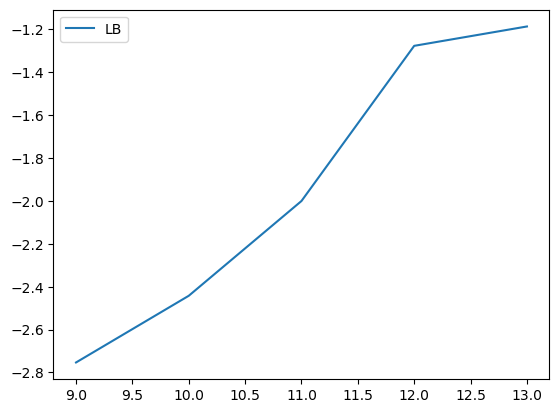

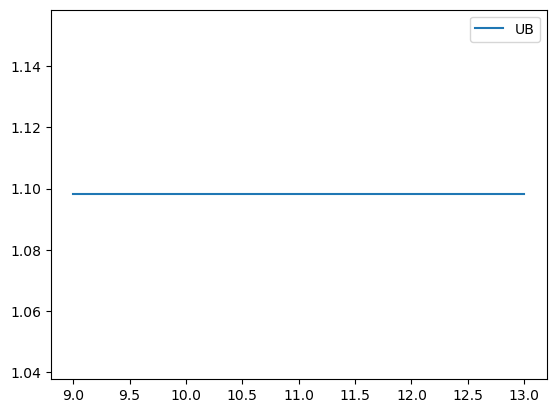

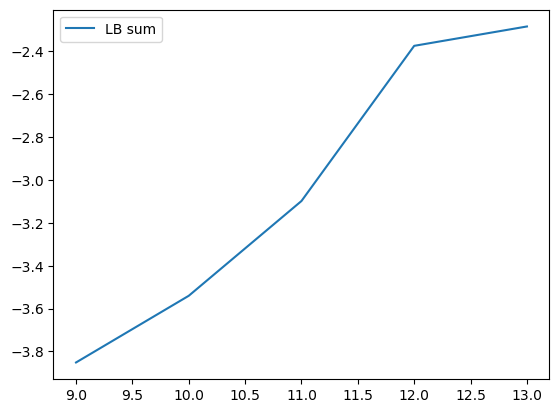

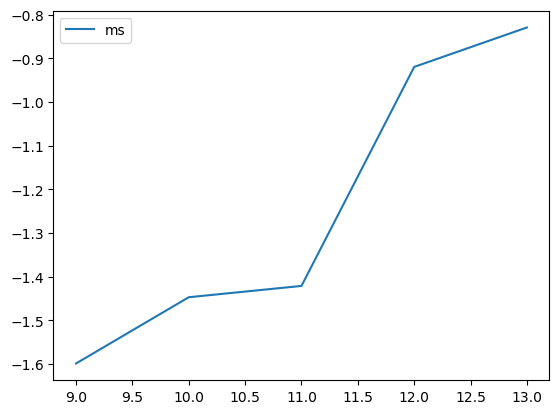

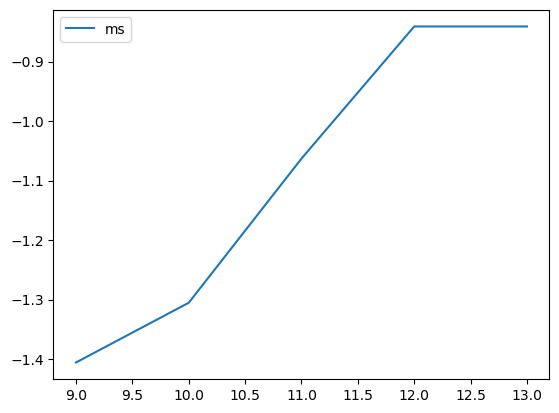

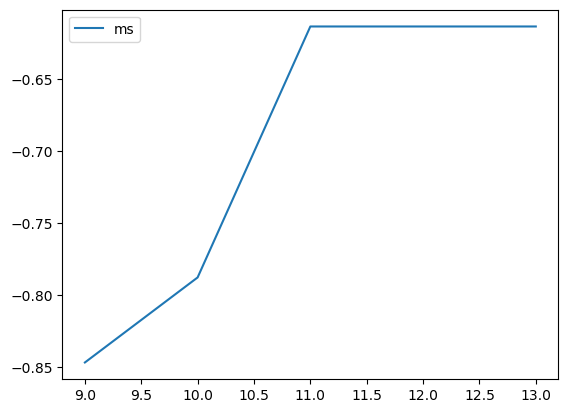

[-1.5990428373367098, -1.4057085142319048, -0.84657994402793]
[-1.4473443105246109, -1.3052865638437618, -0.7876684469868069]
[-1.4214591693422403, -1.0629997836954077, -0.6137936566976071]
[-0.9199087006113178, -0.8408525249837426, -0.613794702622726]
[-0.829627242460756, -0.8408597192846854, -0.6137960680304386]


In [33]:
plt.figure()
plt.plot(k_list, LB_history, label="LB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, UB_history, label="UB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, sum_ms_list, label="LB sum")
plt.legend()
plt.show()

sum_ms_list = []
for i in range(len(ms_history[0])):
    plt.figure()
    plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
    plt.legend()
    plt.show()
    
for item in ms_history:
    print(item)

In [ ]:
def evaluate_As_at(model, first_stg_vars, first_stg_vals, solver):
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(pyo.value(v))
    model.obj = pyo.Objective(expr=As, sense=pyo.minimize)
    results = solver.solve(model, tee=False)

    try:
        results = solver.solve(model, tee=False)
        status_ok = (results.solver.status == SolverStatus.ok)
        term_ok   = (results.solver.termination_condition == TerminationCondition.optimal)
        if not (status_ok and term_ok):
            raise RuntimeError(
                f"Scenario evaluate at y={first_stg_vals} not optimal: "
                f"status={results.solver.status}, term={results.solver.termination_condition}"
            )
        return pyo.value(model.obj_expr)
    finally:
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()
                

In [45]:
# ---- 生成“轴向等距插值点”（）----
def build_full_grid_points(first_stg_vars, n_per_axis=10, endpoint=True, round_ndigits=12):
    """
    生成全维等距笛卡尔网格：
    - first_stg_vars: [Kp, Ki, Kd, ...]，每个变量需要有 lb/ub
    - n_per_axis: int 或 序列（逐维个数），例如 10 或 [10,12,8]
    - endpoint: 是否包含右端点（np.linspace 的参数）
    - round_ndigits: 为了稳定，把坐标四舍五入到固定小数位，避免浮点毛刺造成“相同点判不同”
    返回：list[tuple]，长度为 ∏ n_per_axis
    """
    lbs = [float(v.lb) for v in first_stg_vars]
    ubs = [float(v.ub) for v in first_stg_vars]
    d = len(first_stg_vars)

    if isinstance(n_per_axis, int):
        counts = [n_per_axis] * d
    else:
        if len(n_per_axis) != d:
            raise ValueError("n_per_axis 的长度必须等于维度数")
        counts = list(n_per_axis)

    # 每一维的等距坐标
    grids = [
        np.linspace(lbs[i], ubs[i], counts[i], endpoint=endpoint)
        for i in range(d)
    ]

    # 笛卡尔积 -> 点
    pts = [
        tuple(round(float(x), round_ndigits) for x in coords)
        for coords in it.product(*grids)
    ]
    return pts
n_per_axis = 10
first_stg_grid_nodes = build_full_grid_points(first_stg_vars_list[0], n_per_axis=n_per_axis, endpoint=True, round_ndigits=12)
node_vals = []
for pts in first_stg_grid_nodes:
    node_vals.append(evaluate_As_at(model_list[0], first_stg_vars_list[0], pts, solver))
node_vals

[3.9007114612311216,
 2.3503441048745484,
 1.9104603615508695,
 1.6941793074016234,
 1.5664349008322929,
 1.4824497918564976,
 1.4231620187488767,
 1.3791317594072525,
 1.3451680478984742,
 1.3181867814258266,
 0.3660377086045538,
 0.32095931482637524,
 0.3234540835692534,
 0.3369910821069953,
 0.34605036737259154,
 0.3564343505233331,
 0.3739569496669427,
 0.3962007171844738,
 0.4186998584430933,
 0.4383053800091309,
 0.2147560667825593,
 0.2026925322040548,
 0.23030197311432712,
 0.2510243193151227,
 0.26735514499844354,
 0.28482261451244967,
 0.3013732308080738,
 0.314287711072649,
 0.32400564250854796,
 0.3325285934489534,
 0.16432073421043475,
 0.15990697945187313,
 0.18097721725912347,
 0.20215430340712462,
 0.22021189889336873,
 0.2350134315004603,
 0.24844109773493966,
 0.2622278320994963,
 0.27612077995468576,
 0.28893949406878666,
 0.14116745501822567,
 0.1411070763948227,
 0.15576105715314165,
 0.17305234431627986,
 0.18919173104921766,
 0.20383466602190697,
 0.2167435526661

In [46]:
def scatter_colored_points(first_stg_nodes, node_vals, mode="mpl", highlight_min=True):
    """
    mode: 'mpl' 或 'plotly'
    返回: (best_point, best_value)
    """
    pts = np.asarray(first_stg_nodes, dtype=float)
    vals = np.asarray(node_vals, dtype=float).ravel()
    if pts.size == 0 or vals.size == 0:
        raise ValueError("first_stg_nodes / node_vals 不能为空")
    if pts.shape[1] != 3:
        raise ValueError("first_stg_nodes 需为 N×3 的数组")

    # 最小值点
    idx = int(np.argmin(vals))
    best_point, best_value = pts[idx], float(vals[idx])

    if mode == "plotly":
 
        import pandas as pd
        import plotly.express as px
        import plotly.graph_objects as go
        df = pd.DataFrame({"Kp": pts[:,0], "Ki": pts[:,1], "Kd": pts[:,2], "Value": vals})
        fig = px.scatter_3d(df, x="Kp", y="Ki", z="Kd",
                            color="Value", color_continuous_scale="Viridis",
                            opacity=0.85)
        if highlight_min:
            fig.add_trace(go.Scatter3d(
                x=[best_point[0]], y=[best_point[1]], z=[best_point[2]],
                mode='markers',
                marker=dict(size=8, color='red', symbol='diamond'),
                name='Min Point'
            ))
        fig.update_layout(scene=dict(xaxis_title="Kp", yaxis_title="Ki", zaxis_title="Kd"),
                            title=f"Min value = {best_value:.6g} at {best_point}")
        fig.show()


    if mode == "mpl":
        import matplotlib.pyplot as plt
        fig = plt.figure(figsize=(7,6))
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2],
                        c=vals, cmap='viridis', s=40, alpha=0.8)
        if highlight_min:
            ax.scatter(best_point[0], best_point[1], best_point[2],
                       c='red', s=120, marker='*', label='Min Point', depthshade=False)
            ax.legend(loc="best")
        ax.set_xlabel("Kp"); ax.set_ylabel("Ki"); ax.set_zlabel("Kd")
        cb = fig.colorbar(sc, ax=ax, label="Value")
        ax.set_title(f"Min value = {best_value:.6g} at {best_point}")
        plt.tight_layout(); plt.show()

    return best_point, best_value

bp, bv = scatter_colored_points(first_stg_grid_nodes, node_vals, mode="plotly")

In [14]:
# 先把某个点固定
model_list[0].Kp.fix(1.2)
model_list[0].Ki.fix(0.5)
model_list[0].Kd.fix(0.0)

# 然后直接计算 As
val = pyo.value(As)
print("piecewise value at this point:", val)


piecewise value at this point: 3.4843568749792015


In [12]:
def eval_pw(expr, vars_list, pts):
    vals = []
    for pt in pts:
        context = {v: val for v, val in zip(vars_list, pt)}
        vals.append(pyo.value(expr, context=context))
    return vals

# 使用示例
pts = [(0.5, 0.5, 0.5), (1.0, 0.0, 2.0)]
vals = eval_pw(As, first_stg_vars_list[0], pts)
print(vals)

TypeError: unhashable type: 'ScalarVar'

In [9]:
for i in range(N):
    del_components(model_list[i])
    As, _ = add_nd_piecewise(
        model_list[i],
        first_stg_vars_list[i],
        first_stg_nodes,
        as_nodes_list[i],
        name=f"pw_scen_{i}",
        relation="=="
    )

    # 2) 目标函数：min obj_expr - As_i
    model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

def eval_pw(expr, vars_list, pts):
    vals = []
    for pt in pts:
        context = {v: val for v, val in zip(vars_list, pt)}
        vals.append(pyo.value(expr, context=context))
    return vals

# 使用示例
pts = [(0.5, 0.5, 0.5), (1.0, 0.0, 2.0)]
vals = eval_pw(As, first_stg_vars_list[0], pts)
print(vals)


TypeError: unhashable type: 'ScalarVar'

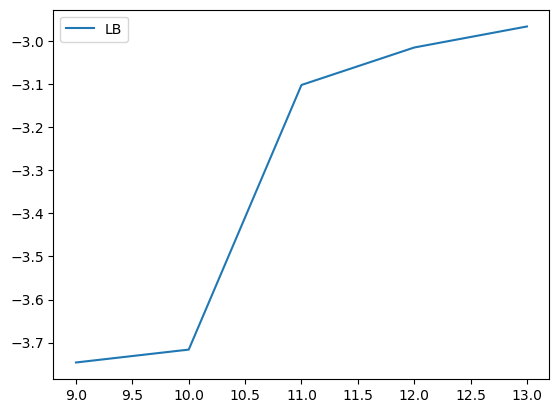

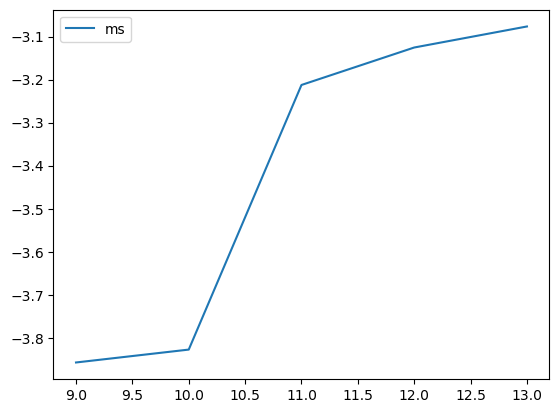

[-3.857168545186457]
[-3.827229109876515]
[-3.212551333575405]
[-3.1255403718660686]
[-3.0766723934664038]


In [2]:
plt.figure()
plt.plot(k_list, LB_list, label="LB")
plt.legend()
plt.show()

for i in range(len(ms_history[0])):
    plt.figure()
    plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
    plt.legend()
    plt.show()
    
for item in ms_history:
    print(item)

In [17]:
for item in fsv_nodes_list:
    print(len(item))
    print(item)

8
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0)]
9
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477)]
10
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817)]
11
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817), (0.9685055475308644, 0.49219590647283035, 4.155587041664758e-10)]
12
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0

In [13]:
UB_node_history

[(10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0)]

8
0


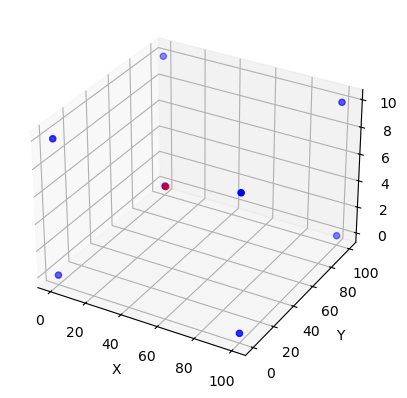

9
1


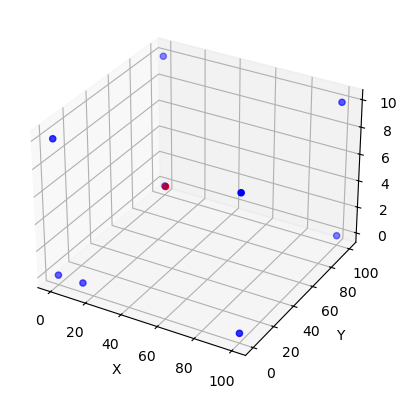

10
2


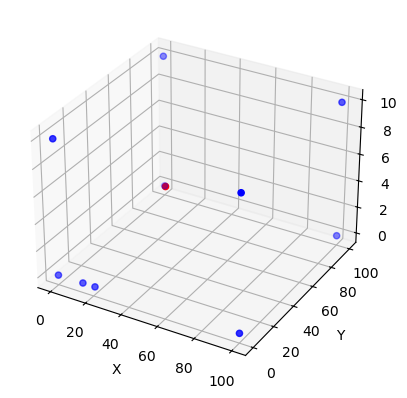

11
3


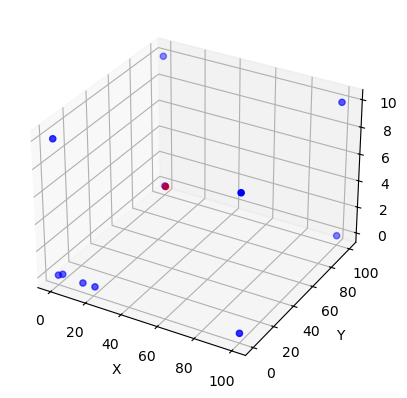

12
4


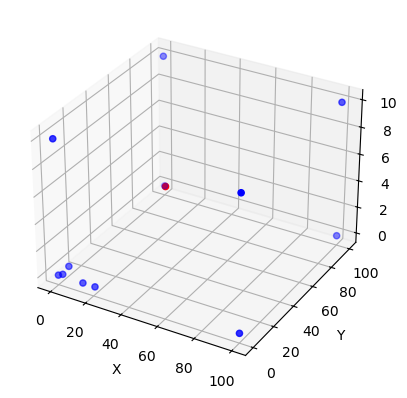

13
5


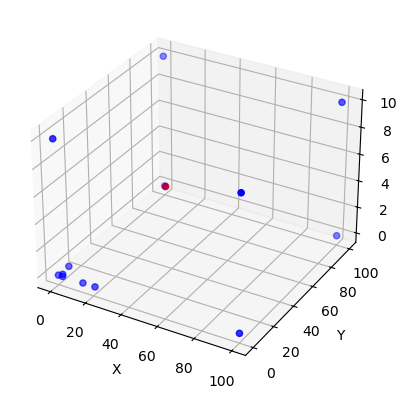

In [18]:
for i in range(len(fsv_nodes_list)):
    points = fsv_nodes_list[i]
    UB_pt = UB_node_history[i]
    print(len(points))
    print(i)
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    zs = [p[2] for p in points]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(xs, ys, zs, c='b', marker='o')
    ax.scatter(UB_pt[0], UB_pt[1], UB_pt[2], c='r', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

In [29]:
# calculate one time
model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
    csv_path, h=0.2, weights=weights, bounds=bounds,
    sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
    disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
    max_scenarios=max_scenarios, skip=0
)
solver2 = SolverFactory('gurobi')
solver2.options.update({
    'MIPGap': 1e-3,
    'FeasibilityTol': 1e-6,
    'IntFeasTol':     1e-6,
    'OptimalityTol':  1e-6,
    'NumericFocus':   0,
    'Presolve':       2,
    'NonConvex':      2,
    'TimeLimit':      120,
    'MIPFocus':       1,
})

# warm start 存储
global warm_solutions
warm_solutions = [None for _ in model_list]


first_stg_nodes = fsv_nodes_list[11]
as_nodes_list = [[] for _ in range(N)]
for i in range(N):
    for node in first_stg_nodes:
        as_nodes_list[i].append(evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, solver2))

print(first_stg_nodes)
print('pts number is ',len(first_stg_nodes))

timeuse = []

for i in range(len(model_list)):
    print('##################################################')
    print('##################################################')
    print('##################################################')
    print('\nSolving scenario ', i)
    del_components(model_list[i])
    As, _ = add_nd_piecewise(
        model_list[i],
        first_stg_vars_list[i],
        first_stg_nodes,
        as_nodes_list[i],
        name=f"pw_scen_{i}",
        relation="=="
    )

    model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

    # 先线性化，再绑定 persistent
    apply_pw_transform(model_list[i])
    assert_no_plf_left(model_list[i], where=f"scenario-{i}")
    apply_warm_values(model_list[i], warm_solutions[i])


    start = time.time()
    #results = opt.solve(tee=True)
    results = solver2.solve(model_list[i], tee=True)
    end = time.time()


    print('**************************************************')
    print('**************************************************')
    print(f"scenario {i}, 计算Q与As最大差值（ms）用时: {end - start:.4f} 秒")
    print('**************************************************')
    print('**************************************************')
    timeuse.append(end - start)

[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817), (0.9685055475308644, 0.49219590647283035, 4.155587041664758e-10), (0.8476346428632943, 0.5062385639700913, 0.0), (1.6558394650127024, 0.0, 0.0), (0.0, 0.7180137951567623, 0.0), (0.3398847059878209, 0.0, 0.8357961904350453), (0.0, 0.0, 2.25606001958985), (1.1905698548827046, 1.1917093697185561, 1.9874603145770062), (0.29453818957864014, 0.14968472981920103, 0.0), (0.5367318701314108, 0.0, 0.0)]
pts number is  19
##################################################
##################################################
##################################################

Solving scenario  0
Read LP format model from file C:\Users\pc\AppData\Local\Temp\tmpl21sks6d.pyomo.lp
Reading time = 0.01 seconds
x1: 81 rows, 267 columns, 1895 nonzeros
